# LIBRO DE INGENIERIA: SISTEMA ORB V38

> **Instrucciones:** Mantener esta celda en modo Markdown para registrar la evolución del modelo.

---

## 🏛️ REQUERIMIENTOS INMUTABLES (BASELINE)

* **Señal:** ORB 5m + Confirmación Delta (5 pts) + Retest al Midpoint.
* **Filtro Marea:** EMA 1h (50p).
* **Gestión:** SL 1R, TP 2R, BE al alcanzar 1R.
* **Frecuencia:** Máximo 1 trade por día.

---

## 🧪 PRUEBA DE HIPOTESIS #1: OPTIMIZACION HORARIA

**Fecha:** 2026-01-06  
**Problema:** El filtro de corte simple (11:00 AM) eliminaba oportunidades rentables en la sesión de la tarde.  
**Hipótesis:** Segmentar la operativa por "Ventanas de Éxito" basadas en Alpha histórico.

### 📊 Resultados Consolidados

| Métrica | Sin Filtro | Filtro 11:00 | **V38 (Ventanas Éxito)** | 
| :--- | :--- | :--- | :--- | 
| **Total Trades** | 2385 | 1382 | **1265** | 
| **Win Rate** | 24.11% | 23.01% | **26.56%** | 
| **Expectancy** | 0.06 R | 0.06 R | **0.14 R** | 
| **Max Drawdown** | -38.17 R | -33.00 R | **-15.00 R** | 
| **Resultado Final** | 149.28 R | 86.87 R | **175.49 R** | 

### 🔒 REQ-EXEC-002: VENTANAS OPERATIVAS (INMUTABLE)

Solo se permite la entrada si la hora se encuentra en:
1. `10:00 - 11:00`
2. `12:00 - 13:00`
3. `14:00 - 15:00`

---

## ✍️ CONCLUSIONES Y NOTAS

* El periodo de *Lunch* (11:00-12:00) y el *Pre-cierre* (15:00-16:00) degradan la curva de equidad.
* La optimización de ventanas redujo el Max Drawdown en un **60%**.
* **Próximo Paso:** Evaluar sensibilidad del Delta de confirmación.

---
*Fin del registro de Hipótesis #1*

In [3]:
import pandas as pd
import numpy as np
import warnings

# Configuración de rutas
FILE_PATH_PARQUET = '/home/quant/data/processed/nq_1m_continuous.parquet'

def capa_0_datos(path):
    """
    Capa 0: Carga, Warm-up de indicadores y Filtrado de Sesión.
    """
    # Silenciamos advertencias de frecuencia si fuera necesario, 
    # aunque lo corregiremos directamente en el código.
    print(f"🚀 Cargando dataset desde: {path}")
    
    # 1. Carga del archivo Parquet
    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index)
    
    # Asegurar que el índice sea local (NY) y sin zona horaria para cálculos rápidos
    if df.index.tz is not None:
        df.index = df.index.tz_convert('America/New_York').tz_localize(None)
    
    # 2. Cálculo de EMAs sobre el dataset COMPLETO (Warm-up)
    
    # EMAs de 1 Minuto
    periodos_1m = [1, 9, 12, 21, 50]
    for p in periodos_1m:
        df[f'EMA_1m_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()
        
    # EMAs de 1 Hora (Estructurales)
    # Corrección de Warning: usamos '1h' en lugar de '1H'
    df_1h = df.resample('1h').last().copy()
    periodos_1h = [20, 50, 100, 200]
    for p in periodos_1h:
        df_1h[f'EMA_1h_{p}'] = df_1h['Close'].ewm(span=p, adjust=False).mean()
    
    # Desplazamos 1 periodo las EMAs de 1h para usar solo info CERRADA
    # Nota: Esto genera NaNs en el primer registro histórico de la base de datos
    df_1h_shifted = df_1h[[f'EMA_1h_{p}' for p in periodos_1h]].shift(1)
    
    # Unir EMAs 1h al dataframe principal
    df = df.join(df_1h_shifted, how='left')
    df[[f'EMA_1h_{p}' for p in periodos_1h]] = df[[f'EMA_1h_{p}' for p in periodos_1h]].ffill()
    
    # 3. Filtrado de Sesión Operativa
    # Recortamos el dataframe para el backtest (09:30 a 18:00)
    df_session = df.between_time('09:30', '18:00').copy()
    
    # Limpieza de registros iniciales sin indicadores calculados (NaNs de la EMA 200h)
    # Esto elimina los primeros días del historial donde la EMA200h aún no existe.
    df_session = df_session.dropna(subset=[f'EMA_1h_200'])
    
    print(f"✅ Capa 0 Completada (Warning corregido y NaNs filtrados).")
    print(f"Velas procesadas: {len(df_session)}")
    print(f"Rango operativo real: {df_session.index.min()} a {df_session.index.max()}")
    
    return df_session

# --- EJECUCIÓN ---
df_ready = capa_0_datos(FILE_PATH_PARQUET)
df_ready.head()

🚀 Cargando dataset desde: /home/quant/data/processed/nq_1m_continuous.parquet
✅ Capa 0 Completada (Warning corregido y NaNs filtrados).
Velas procesadas: 1738894
Rango operativo real: 2010-06-07 09:30:00 a 2025-12-12 16:59:00


,Open,High,Low,Close,Volume,Ticker,EMA_1m_1,EMA_1m_9,EMA_1m_12,EMA_1m_21,EMA_1m_50,EMA_1h_20,EMA_1h_50,EMA_1h_100,EMA_1h_200
timestamp,,,,,,,,,,,,,,,
2010-06-07 09:30:00,1841.25,1842.00,1838.75,1841.00,3113,NQM0,1841.00,1840.032226,1839.864509,1839.805139,1840.221120,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:31:00,1840.75,1843.75,1840.50,1842.75,1596,NQM0,1842.75,1840.575781,1840.308431,1840.072854,1840.320292,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:32:00,1842.75,1844.25,1841.50,1843.75,1377,NQM0,1843.75,1841.210625,1840.837903,1840.407140,1840.454791,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:33:00,1843.75,1844.00,1839.50,1839.50,1274,NQM0,1839.50,1840.868500,1840.632072,1840.324672,1840.417348,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:34:00,1839.50,1840.75,1837.00,1837.75,1566,NQM0,1837.75,1840.244800,1840.188676,1840.090611,1840.312746,1827.324773,1823.387119,1821.781056,1820.913594


In [ ]:
import pandas as pd
import numpy as np

def generar_trades_orb(df, breakout_delta=5.0):
    """
    Capa 1: Lógica de detección de ORB, confirmación de Breakout y ejecución en Midpoint.
    Limitado a 1 trade por día.
    """
    print(f"distancia de confirmación (BreakoutDelta): {breakout_delta} puntos.")
    
    # 1. Identificar días únicos en el dataset
    df['date'] = df.index.date
    unique_days = df['date'].unique()
    trades = []

    for day in unique_days:
        # Filtrar data del día
        df_day = df[df['date'] == day].copy()
        
        # 2. Definir el Rango ORB (09:30 - 09:34 inclusive)
        # Las primeras 5 velas de 1m definen el rango de 5m
        orb_data = df_day.between_time('09:30', '09:34')
        if len(orb_data) < 5:
            continue
            
        orb_h = orb_data['High'].max()
        orb_l = orb_data['Low'].min()
        orb_m = (orb_h + orb_l) / 2
        
        # 3. Buscar Confirmación de Breakout (Post 09:34)
        # Solo evaluamos velas a partir de las 09:35
        post_orb = df_day.between_time('09:35', '16:00')
        
        confirmed_dir = None
        confirmation_time = None
        
        for ts, row in post_orb.iterrows():
            # Condición Long: Vela completa a distancia Delta sobre el High
            if row['Low'] >= (orb_h + breakout_delta):
                confirmed_dir = 'Long'
                confirmation_time = ts
                break
            
            # Condición Short: Vela completa a distancia Delta bajo el Low
            if row['High'] <= (orb_l - breakout_delta):
                confirmed_dir = 'Short'
                confirmation_time = ts
                break
        
        # 4. Si hay confirmación, buscar Retest al Midpoint
        if confirmed_dir:
            # Buscamos la entrada desde el minuto siguiente a la confirmación
            retest_data = post_orb.loc[confirmation_time:].iloc[1:]
            
            entry_time = None
            entry_price = orb_m
            
            for ts_entry, row_entry in retest_data.iterrows():
                # El precio debe cruzar o tocar el midpoint para gatillar
                if confirmed_dir == 'Long':
                    # En un Long, venimos de arriba, buscamos Low <= Midpoint
                    if row_entry['Low'] <= orb_m:
                        entry_time = ts_entry
                        break
                else:
                    # En un Short, venimos de abajo, buscamos High >= Midpoint
                    if row_entry['High'] >= orb_m:
                        entry_time = ts_entry
                        break
            
            # 5. Registrar el Trade si hubo entrada
            if entry_time:
                # Valores adicionales importantes para optimización
                trade_info = {
                    'fecha': day,
                    'orb_high': orb_h,
                    'orb_low': orb_l,
                    'midpoint': orb_m,
                    'direccion': confirmed_dir,
                    'confirmacion_dt': confirmation_time,
                    'entrada_dt': entry_time,
                    'entrada_precio': entry_price,
                    # Referencias de mercado al momento de entrada
                    'ema_1h_50_entry': row_entry['EMA_1h_50'],
                    'ema_1m_21_entry': row_entry['EMA_1m_21'],
                    'ticker': row_entry['Ticker']
                }
                trades.append(trade_info)
                # Req Inmutable: Solo 1 trade al día. Pasamos al siguiente día.
                continue

    # Convertir a DataFrame de Trades
    df_trades = pd.DataFrame(trades)
    
    if not df_trades.empty:
        df_trades['entrada_dt'] = pd.to_datetime(df_trades['entrada_dt'])
        print(f"✅ Procesamiento completado. Trades generados: {len(df_trades)}")
    else:
        print("⚠️ No se generaron trades con los parámetros actuales.")
        
    return df_trades

# --- EJECUCIÓN ---
# Nota: df_ready viene de la Capa 0
df_trades_raw = generar_trades_orb(df_ready, breakout_delta=5.0)
df_trades_raw.head()

distancia de confirmación (BreakoutDelta): 5.0 puntos.


In [3]:
import pandas as pd
import numpy as np

def simular_gestion_riesgo(df_ready, df_trades, breakout_delta=5.0):
    """
    Capa 2: Simulación de gestión de riesgo con modelo secuencial OHLC/OLHC.
    Salidas: TP (2R), SL (Extremo ORB), BE (al tocar 1R).
    """
    print(f"🚀 Iniciando gestión de riesgo para {len(df_trades)} trades...")
    
    resultados = []

    for _, trade in df_trades.iterrows():
        # Extraer parámetros del trade
        entry_price = trade['entrada_precio']
        direction = trade['direccion']
        orb_h = trade['orb_high']
        orb_l = trade['orb_low']
        
        # Calcular distancias de riesgo (R)
        # R es la distancia del midpoint al extremo del ORB
        risk_r = abs(entry_price - (orb_l if direction == 'Long' else orb_h))
        
        stop_loss = orb_l if direction == 'Long' else orb_h
        take_profit = entry_price + (2 * risk_r) if direction == 'Long' else entry_price - (2 * risk_r)
        be_trigger = entry_price + risk_r if direction == 'Long' else entry_price - risk_r
        
        # Obtener data desde el minuto de entrada hasta el fin de sesión
        df_day = df_ready[df_ready.index.date == trade['fecha']]
        df_post_entry = df_day.loc[trade['entrada_dt']:]
        
        current_sl = stop_loss
        be_activated = False
        exit_price = None
        exit_time = None
        exit_reason = None
        
        for ts, row in df_post_entry.iterrows():
            # Modelo Secuencial OHLC/OLHC para resolver conflictos intra-vela
            if row['Open'] <= row['Close']:
                # Vela Alcista: Open -> Low -> High -> Close
                sequence = [row['Open'], row['Low'], row['High'], row['Close']]
            else:
                # Vela Bajista: Open -> High -> Low -> Close
                sequence = [row['Open'], row['High'], row['Low'], row['Close']]
                
            for price_point in sequence:
                # 1. Verificar Trigger de Break Even (1R)
                if not be_activated:
                    if (direction == 'Long' and price_point >= be_trigger) or \
                       (direction == 'Short' and price_point <= be_trigger):
                        current_sl = entry_price
                        be_activated = True
                
                # 2. Verificar Stop Loss (o BE si ya se activó)
                if (direction == 'Long' and price_point <= current_sl) or \
                   (direction == 'Short' and price_point >= current_sl):
                    exit_price = current_sl
                    exit_time = ts
                    exit_reason = 'SL' if not be_activated else 'BE'
                    break
                
                # 3. Verificar Take Profit (2R)
                if (direction == 'Long' and price_point >= take_profit) or \
                   (direction == 'Short' and price_point <= take_profit):
                    exit_price = take_profit
                    exit_time = ts
                    exit_reason = 'TP'
                    break
            
            if exit_time: break
            
        # 4. Cierre forzado EOD si no salió por niveles
        if not exit_time:
            exit_price = df_post_entry['Close'].iloc[-1]
            exit_time = df_post_entry.index[-1]
            exit_reason = 'EOD'

        # Cálculo de PnL en R
        pnl_r = (exit_price - entry_price) / risk_r if direction == 'Long' else (entry_price - exit_price) / risk_r
        
        # Guardar resultado extendido
        res = trade.to_dict()
        res.update({
            'salida_dt': exit_time,
            'salida_precio': exit_price,
            'motivo': exit_reason,
            'pnl_r': pnl_r,
            'be_activado': be_activated,
            'risk_r_puntos': risk_r
        })
        resultados.append(res)

    df_results = pd.DataFrame(resultados)
    print(f"✅ Gestión completada. Win Rate: {(df_results['pnl_r'] > 0).mean():.2%}")
    return df_results

# --- EJECUCIÓN ---
# df_ready (Capa 0) y df_trades_raw (Capa 1) deben estar en memoria
df_final_results = simular_gestion_riesgo(df_ready, df_trades_raw)
df_final_results[['fecha', 'direccion', 'motivo', 'pnl_r']].head(10)

🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 24.11%


,fecha,direccion,motivo,pnl_r
0,2010-06-07,Short,SL,-1.0
1,2010-06-08,Short,TP,2.0
2,2010-06-09,Short,BE,0.0
3,2010-06-10,Long,TP,2.0
4,2010-06-14,Long,BE,0.0
5,2010-06-17,Short,TP,2.0
6,2010-06-18,Long,SL,-1.0
7,2010-06-22,Long,BE,0.0
8,2010-06-23,Short,SL,-1.0
9,2010-06-24,Short,SL,-1.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluar_estrategia(df_results):
    """
    Capa 4: Evaluación de métricas, análisis estadístico y visualización.
    """
    print("📊 Generando reporte de evaluación...")
    
    # 1. Cálculos de Retorno Acumulado
    df_results = df_results.sort_values('fecha').copy()
    df_results['pnl_acumulado'] = df_results['pnl_r'].cumsum()
    
    # 2. Métricas Clave
    total_trades = len(df_results)
    win_rate = (df_results['pnl_r'] > 0).mean()
    be_rate = (df_results['pnl_r'] == 0).mean()
    loss_rate = (df_results['pnl_r'] < 0).mean()
    
    profit_factor = abs(df_results[df_results['pnl_r'] > 0]['pnl_r'].sum() / 
                        df_results[df_results['pnl_r'] < 0]['pnl_r'].sum())
    
    expectancy = df_results['pnl_r'].mean() # Esperanza matemática por trade en R
    
    # Drawdown en R
    rolling_max = df_results['pnl_acumulado'].cummax()
    drawdown = df_results['pnl_acumulado'] - rolling_max
    max_drawdown = drawdown.min()
    
    # 3. Impresión de Reporte
    print("-" * 30)
    print(f"📈 REPORTE DE PERFORMANCE")
    print("-" * 30)
    print(f"Total Trades:      {total_trades}")
    print(f"Win Rate:          {win_rate:.2%}")
    print(f"BE Rate:           {be_rate:.2%}")
    print(f"Loss Rate:         {loss_rate:.2%}")
    print(f"Expectancy:        {expectancy:.2f} R")
    print(f"Profit Factor:     {profit_factor:.2f}")
    print(f"Max Drawdown:      {max_drawdown:.2f} R")
    print(f"Resultado Final:   {df_results['pnl_acumulado'].iloc[-1]:.2f} R")
    print("-" * 30)

    # 4. Visualización
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # A. Curva de Equidad
    axes[0, 0].plot(df_results['fecha'], df_results['pnl_acumulado'], color='#2563eb', lw=2)
    axes[0, 0].set_title("Curva de Equidad (Acumulado R)")
    axes[0, 0].grid(alpha=0.3)
    
    # B. Distribución de Motivos de Salida
    motivo_counts = df_results['motivo'].value_counts()
    axes[0, 1].pie(motivo_counts, labels=motivo_counts.index, autopct='%1.1f%%', 
                  colors=['#10b981', '#ef4444', '#f59e0b', '#64748b'])
    axes[0, 1].set_title("Distribución de Salidas")
    
    # C. PnL por Día de la Semana
    df_results['dia_semana'] = pd.to_datetime(df_results['fecha']).dt.day_name()
    order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    sns.barplot(x='dia_semana', y='pnl_r', data=df_results, order=order, ax=axes[1, 0], palette='viridis')
    axes[1, 0].set_title("Expectancia (R) por Día de la Semana")
    
    # D. Histograma de PnL
    axes[1, 1].hist(df_results['pnl_r'], bins=20, color='#8b5cf6', edgecolor='white')
    axes[1, 1].set_title("Distribución de Resultados (R)")
    
    plt.tight_layout()
    plt.show()
    
    return df_results

# --- EJECUCIÓN ---
# df_final_results debe ser el DataFrame generado por la Capa 2
df_evaluado = evaluar_estrategia(df_final_results)

📊 Generando reporte de evaluación detallado...
--------------------------------------------------
📈 REPORTE DE PERFORMANCE ESTRATEGIA ORB
--------------------------------------------------
Total Trades:      2385
Win Rate:          24.11%
BE Rate:           34.84%
Loss Rate:         41.05%
Expectancy:        0.06 R
Profit Factor:     1.15
Max Drawdown:      -38.17 R
Resultado Final:   149.28 R
--------------------------------------------------

📅 RENDIMIENTO DESGLOSADO POR AÑO:
 year  Trades Resultado_R Win_Rate Expectancy
 2010      65      -10.93   16.92%      -0.17
 2011     123      -11.00   17.89%      -0.09
 2012     116       19.61   25.86%       0.17
 2013     122        1.13   18.03%       0.01
 2014     133       -1.14   24.06%      -0.01
 2015     161        5.86   24.84%       0.04
 2016     146       15.76   24.66%       0.11
 2017     125      -16.17   14.40%      -0.13
 2018     177      -15.00   18.08%      -0.08
 2019     155       30.18   28.39%       0.19
 2020     1

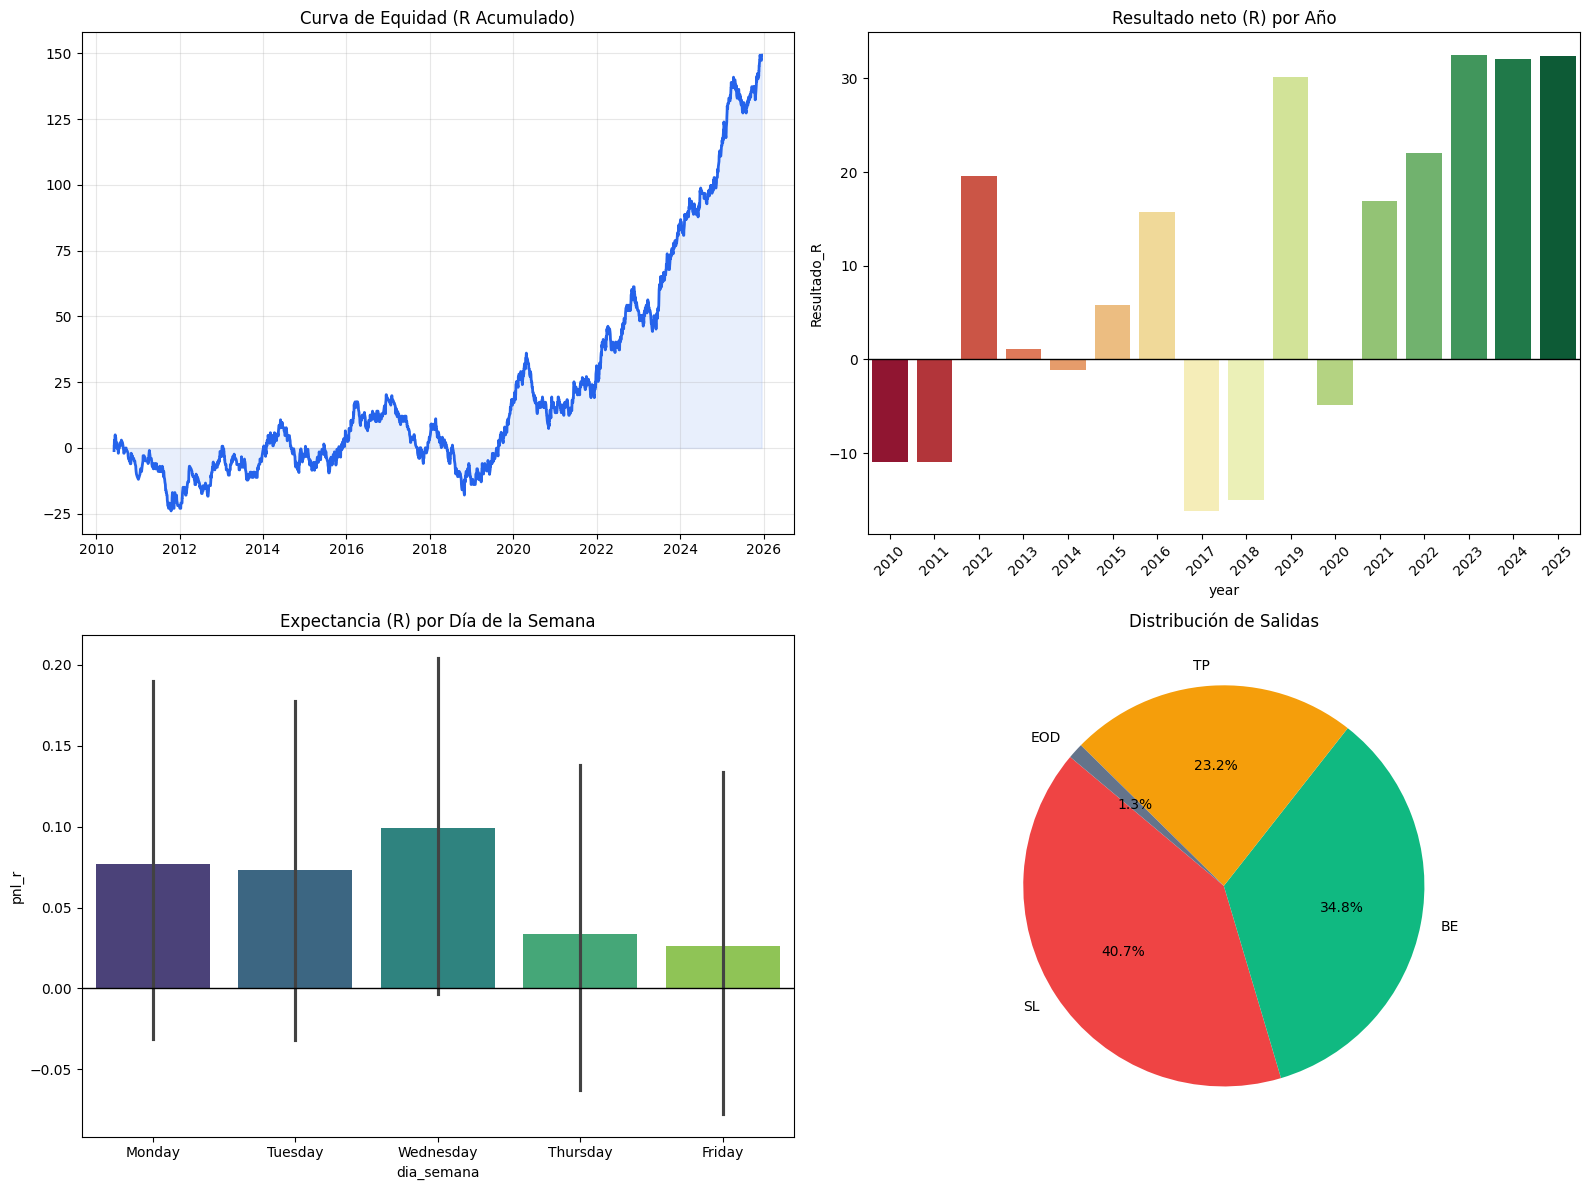

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluar_estrategia(df_results):
    """
    Capa 4: Evaluación de métricas, análisis estadístico y visualización.
    Incluye desglose detallado de rendimiento por año.
    """
    if df_results is None or df_results.empty:
        print("⚠️ No hay datos para evaluar.")
        return None

    print("📊 Generando reporte de evaluación detallado...")
    
    # 1. Preparación de datos temporales
    df_results = df_results.sort_values('fecha').copy()
    df_results['fecha_dt'] = pd.to_datetime(df_results['fecha'])
    df_results['year'] = df_results['fecha_dt'].dt.year
    df_results['pnl_acumulado'] = df_results['pnl_r'].cumsum()
    
    # 2. Cálculo de métricas anuales
    annual_metrics = df_results.groupby('year').agg(
        Trades=('pnl_r', 'count'),
        Resultado_R=('pnl_r', 'sum'),
        Win_Rate=('pnl_r', lambda x: (x > 0).mean()),
        Expectancy=('pnl_r', 'mean')
    ).reset_index()

    # 3. Métricas Globales
    total_trades = len(df_results)
    win_rate = (df_results['pnl_r'] > 0).mean()
    be_rate = (df_results['pnl_r'] == 0).mean()
    loss_rate = (df_results['pnl_r'] < 0).mean()
    
    gross_profits = df_results[df_results['pnl_r'] > 0]['pnl_r'].sum()
    gross_losses = abs(df_results[df_results['pnl_r'] < 0]['pnl_r'].sum())
    profit_factor = gross_profits / gross_losses if gross_losses > 0 else np.inf
    
    expectancy = df_results['pnl_r'].mean()
    
    rolling_max = df_results['pnl_acumulado'].cummax()
    drawdown = df_results['pnl_acumulado'] - rolling_max
    max_drawdown = drawdown.min()
    
    # 4. Impresión de Reporte por Consola
    print("-" * 50)
    print(f"📈 REPORTE DE PERFORMANCE ESTRATEGIA ORB")
    print("-" * 50)
    print(f"Total Trades:      {total_trades}")
    print(f"Win Rate:          {win_rate:.2%}")
    print(f"BE Rate:           {be_rate:.2%}")
    print(f"Loss Rate:         {loss_rate:.2%}")
    print(f"Expectancy:        {expectancy:.2f} R")
    print(f"Profit Factor:     {profit_factor:.2f}")
    print(f"Max Drawdown:      {max_drawdown:.2f} R")
    print(f"Resultado Final:   {df_results['pnl_acumulado'].iloc[-1]:.2f} R")
    print("-" * 50)

    print("\n📅 RENDIMIENTO DESGLOSADO POR AÑO:")
    tabla_anual = annual_metrics.copy()
    tabla_anual['Win_Rate'] = tabla_anual['Win_Rate'].map('{:,.2%}'.format)
    tabla_anual['Resultado_R'] = tabla_anual['Resultado_R'].map('{:,.2f}'.format)
    tabla_anual['Expectancy'] = tabla_anual['Expectancy'].map('{:,.2f}'.format)
    print(tabla_anual.to_string(index=False))
    print("-" * 50)

    # 5. Visualización Gráfica
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Gráfico A: Curva de Equidad
    axes[0, 0].plot(df_results['fecha_dt'], df_results['pnl_acumulado'], color='#2563eb', lw=2)
    axes[0, 0].fill_between(df_results['fecha_dt'], df_results['pnl_acumulado'], color='#2563eb', alpha=0.1)
    axes[0, 0].set_title("Curva de Equidad (R Acumulado)")
    axes[0, 0].grid(alpha=0.3)
    
    # Gráfico B: Resultado R por Año
    sns.barplot(x='year', y='Resultado_R', data=annual_metrics, ax=axes[0, 1], hue='year', palette='RdYlGn', legend=False)
    axes[0, 1].axhline(0, color='black', lw=1)
    axes[0, 1].set_title("Resultado neto (R) por Año")
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Gráfico C: Expectancia por Día de la Semana
    df_results['dia_semana'] = df_results['fecha_dt'].dt.day_name()
    order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    sns.barplot(x='dia_semana', y='pnl_r', data=df_results, order=order, ax=axes[1, 0], hue='dia_semana', palette='viridis', legend=False)
    axes[1, 0].axhline(0, color='black', lw=1)
    axes[1, 0].set_title("Expectancia (R) por Día de la Semana")
    
    # Gráfico D: Distribución de motivos de salida
    motivo_counts = df_results['motivo'].value_counts()
    axes[1, 1].pie(motivo_counts, labels=motivo_counts.index, autopct='%1.1f%%', colors=['#ef4444', '#10b981', '#f59e0b', '#64748b'], startangle=140)
    axes[1, 1].set_title("Distribución de Salidas")
    
    plt.tight_layout()
    plt.show()
    
    return annual_metrics

# --- EJECUCIÓN ---
analisis_anual = evaluar_estrategia(df_final_results)

🔍 Aplicando filtros operativos...
   - Restricción horaria: Solo entradas antes de las 11:00
✅ Filtrado completado.
   - Trades originales: 2385
   - Trades eliminados:  1003
   - Trades restantes:   1382
🚀 Iniciando gestión de riesgo para 1382 trades...
✅ Gestión completada. Win Rate: 23.01%
📊 Generando reporte de evaluación detallado...
--------------------------------------------------
📈 REPORTE DE PERFORMANCE ESTRATEGIA ORB
--------------------------------------------------
Total Trades:      1382
Win Rate:          23.01%
BE Rate:           37.19%
Loss Rate:         39.80%
Expectancy:        0.06 R
Profit Factor:     1.16
Max Drawdown:      -33.00 R
Resultado Final:   86.87 R
--------------------------------------------------

📅 RENDIMIENTO DESGLOSADO POR AÑO:
 year  Trades Resultado_R Win_Rate Expectancy
 2010      20       -4.00   10.00%      -0.20
 2011      51       -8.00   15.69%      -0.16
 2012      32        9.00   31.25%       0.28
 2013      39        0.00   17.95%      

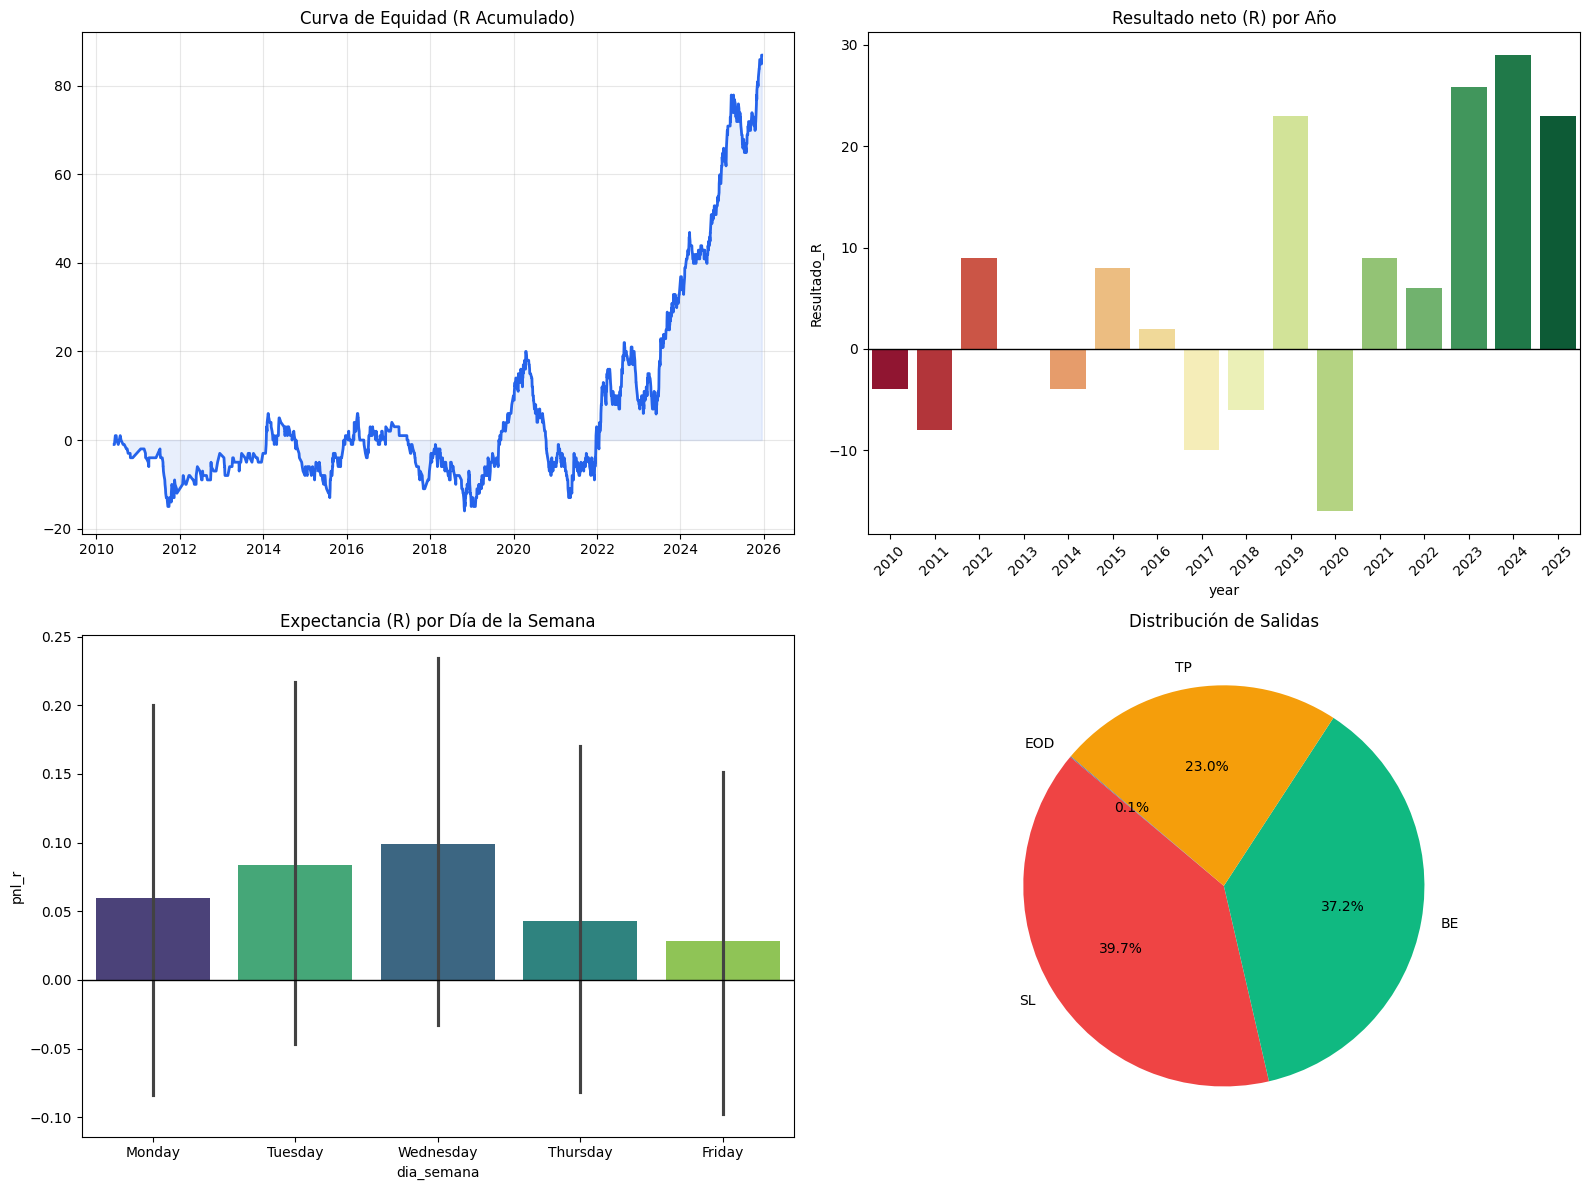

In [6]:
import pandas as pd

def aplicar_filtros(df_trades_raw, limite_hora="11:00"):
    """
    Capa 3: Filtros de selección de trades.
    Aplica restricciones temporales, estructurales o técnicas.
    """
    print(f"🔍 Aplicando filtros operativos...")
    print(f"   - Restricción horaria: Solo entradas antes de las {limite_hora}")
    
    total_inicial = len(df_trades_raw)
    
    # 1. Filtro de Hora (Solo trades cuya entrada_dt sea <= limite_hora)
    # Convertimos el límite a un objeto time para comparar
    hora_limite = pd.to_datetime(limite_hora).time()
    
    df_filtrado = df_trades_raw[
        df_trades_raw['entrada_dt'].dt.time <= hora_limite
    ].copy()
    
    total_final = len(df_filtrado)
    eliminados = total_inicial - total_final
    
    print(f"✅ Filtrado completado.")
    print(f"   - Trades originales: {total_inicial}")
    print(f"   - Trades eliminados:  {eliminados}")
    print(f"   - Trades restantes:   {total_final}")
    
    return df_filtrado

# --- EJECUCIÓN DEL FLUJO ACTUALIZADO ---

# 1. Filtramos los trades detectados en la Capa 1
df_trades_filtrados = aplicar_filtros(df_trades_raw, limite_hora="11:00")

# 2. Pasamos los trades filtrados a la Capa 2 (Gestión de Riesgo)
# Nota: Usamos df_trades_filtrados en lugar de df_trades_raw
df_final_results_filtrado = simular_gestion_riesgo(df_ready, df_trades_filtrados)

# 3. Evaluamos el impacto con la Capa 4
analisis_anual_filtrado = evaluar_estrategia(df_final_results_filtrado)

In [7]:
import pandas as pd
import numpy as np

def analizar_rendimiento_por_horas(df_results):
    """
    Desglosa el rendimiento de los trades por su hora de ejecución (entrada_dt).
    Ayuda a identificar las ventanas horarias más rentables y las que generan 'ruido'.
    """
    if df_results is None or df_results.empty:
        print("⚠️ No hay datos para analizar.")
        return
    
    df = df_results.copy()
    
    # Asegurar que entrada_dt sea datetime
    df['entrada_dt'] = pd.to_datetime(df['entrada_dt'])
    
    # Definir las etiquetas de las ventanas horarias
    # Usamos cortes de 30 minutos para ver el detalle de la apertura
    bins = [
        pd.Timestamp("09:30").time(),
        pd.Timestamp("10:00").time(),
        pd.Timestamp("10:30").time(),
        pd.Timestamp("11:00").time(),
        pd.Timestamp("11:30").time(),
        pd.Timestamp("12:00").time(),
        pd.Timestamp("13:00").time(),
        pd.Timestamp("14:00").time(),
        pd.Timestamp("15:00").time(),
        pd.Timestamp("16:00").time()
    ]
    
    labels = [
        "09:30-10:00", "10:00-10:30", "10:30-11:00", 
        "11:00-11:30", "11:30-12:00", "12:00-13:00",
        "13:00-14:00", "14:00-15:00", "15:00-16:00"
    ]
    
    # Extraer la hora de entrada para clasificar
    df['time_only'] = df['entrada_dt'].dt.time
    
    def clasificar_ventana(t):
        for i in range(len(bins)-1):
            if bins[i] <= t < bins[i+1]:
                return labels[i]
        return "Fuera de Rango"

    df['ventana_horaria'] = df['time_only'].apply(clasificar_ventana)
    
    # Agrupación y métricas
    tabla_granular = df.groupby('ventana_horaria').agg(
        Trades=('pnl_r', 'count'),
        Resultado_R=('pnl_r', 'sum'),
        Win_Rate=('pnl_r', lambda x: (x > 0).mean()),
        Expectancy=('pnl_r', 'mean'),
        Max_Profit=('pnl_r', 'max'),
        Max_Loss=('pnl_r', 'min')
    ).reindex(labels) # Reindexamos para mantener el orden cronológico

    print("📊 ANÁLISIS GRANULAR POR VENTANAS DE ENTRADA")
    print("-" * 80)
    
    # Formateo para impresión
    reporte = tabla_granular.copy()
    reporte['Resultado_R'] = reporte['Resultado_R'].map('{:,.2f}'.format)
    reporte['Win_Rate'] = reporte['Win_Rate'].map('{:,.2%}'.format)
    reporte['Expectancy'] = reporte['Expectancy'].map('{:,.2f}'.format)
    
    print(reporte.reset_index().to_string(index=False))
    print("-" * 80)
    
    return tabla_granular

# --- EJECUCIÓN ---
# Nota: Ejecutar sobre el DataFrame original de 2385 trades (df_final_results)
# para ver qué ventanas estamos perdiendo.
stats_horarias = analizar_rendimiento_por_horas(df_final_results)

📊 ANÁLISIS GRANULAR POR VENTANAS DE ENTRADA
--------------------------------------------------------------------------------
ventana_horaria  Trades Resultado_R Win_Rate Expectancy  Max_Profit  Max_Loss
    09:30-10:00     443       -1.00   20.32%      -0.00         2.0      -1.0
    10:00-10:30     605       69.00   23.97%       0.11         2.0      -1.0
    10:30-11:00     323       22.87   25.39%       0.07         2.0      -1.0
    11:00-11:30     231       -4.60   22.94%      -0.02         2.0      -1.0
    11:30-12:00     148        2.00   22.97%       0.01         2.0      -1.0
    12:00-13:00     188       39.49   31.91%       0.21         2.0      -1.0
    13:00-14:00     164       -8.41   21.34%      -0.05         2.0      -1.0
    14:00-15:00     149       44.13   32.89%       0.30         2.0      -1.0
    15:00-16:00     128      -14.33   20.31%      -0.11         2.0      -1.0
--------------------------------------------------------------------------------


In [9]:
import pandas as pd
import numpy as np

def analizar_rendimiento_por_horas(df_results):
    """
    Desglosa el rendimiento de los trades por su hora de ejecución (entrada_dt).
    Ayuda a identificar las ventanas horarias más rentables y las que generan 'ruido'.
    """
    if df_results is None or df_results.empty:
        print("⚠️ No hay datos para analizar.")
        return None
    
    df = df_results.copy()
    
    # Asegurar que entrada_dt sea datetime
    df['entrada_dt'] = pd.to_datetime(df['entrada_dt'])
    
    # Definir las etiquetas de las ventanas horarias
    bins = [
        pd.Timestamp("09:30").time(),
        pd.Timestamp("10:00").time(),
        pd.Timestamp("10:30").time(),
        pd.Timestamp("11:00").time(),
        pd.Timestamp("11:30").time(),
        pd.Timestamp("12:00").time(),
        pd.Timestamp("13:00").time(),
        pd.Timestamp("14:00").time(),
        pd.Timestamp("15:00").time(),
        pd.Timestamp("16:00").time()
    ]
    
    labels = [
        "09:30-10:00", "10:00-10:30", "10:30-11:00", 
        "11:00-11:30", "11:30-12:00", "12:00-13:00",
        "13:00-14:00", "14:00-15:00", "15:00-16:00"
    ]
    
    # Extraer la hora de entrada para clasificar
    df['time_only'] = df['entrada_dt'].dt.time
    
    def clasificar_ventana(t):
        for i in range(len(bins)-1):
            if bins[i] <= t < bins[i+1]:
                return labels[i]
        return "Fuera de Rango"

    df['ventana_horaria'] = df['time_only'].apply(clasificar_ventana)
    
    # Agrupación y métricas
    tabla_granular = df.groupby('ventana_horaria').agg(
        Trades=('pnl_r', 'count'),
        Resultado_R=('pnl_r', 'sum'),
        Win_Rate=('pnl_r', lambda x: (x > 0).mean()),
        Expectancy=('pnl_r', 'mean'),
        Max_Profit=('pnl_r', 'max'),
        Max_Loss=('pnl_r', 'min')
    ).reindex(labels)

    print("📊 ANÁLISIS GRANULAR POR VENTANAS DE ENTRADA")
    print("-" * 80)
    
    reporte = tabla_granular.copy()
    reporte['Resultado_R'] = reporte['Resultado_R'].map('{:,.2f}'.format)
    reporte['Win_Rate'] = reporte['Win_Rate'].map('{:,.2%}'.format)
    reporte['Expectancy'] = reporte['Expectancy'].map('{:,.2f}'.format)
    
    print(reporte.reset_index().to_string(index=False))
    print("-" * 80)
    
    return tabla_granular

def aplicar_filtro_ventanas_exito(df_results, ventanas_permitidas):
    """
    Filtra los resultados basándose únicamente en las ventanas horarias validadas.
    """
    print(f"🎯 Aplicando filtro de ventanas de éxito: {ventanas_permitidas}")
    
    df = df_results.copy()
    df['entrada_dt'] = pd.to_datetime(df['entrada_dt'])
    df['time_only'] = df['entrada_dt'].dt.time
    
    # Re-clasificar para filtrar
    def obtener_ventana(t):
        bins = [pd.Timestamp("09:30").time(), pd.Timestamp("10:00").time(), pd.Timestamp("10:30").time(),
                pd.Timestamp("11:00").time(), pd.Timestamp("11:30").time(), pd.Timestamp("12:00").time(),
                pd.Timestamp("13:00").time(), pd.Timestamp("14:00").time(), pd.Timestamp("15:00").time(),
                pd.Timestamp("16:00").time()]
        labels = ["09:30-10:00", "10:00-10:30", "10:30-11:00", "11:00-11:30", "11:30-12:00", 
                  "12:00-13:00", "13:00-14:00", "14:00-15:00", "15:00-16:00"]
        for i in range(len(bins)-1):
            if bins[i] <= t < bins[i+1]: return labels[i]
        return None

    df['ventana'] = df['time_only'].apply(obtener_ventana)
    df_filtrado = df[df['ventana'].isin(ventanas_permitidas)].copy()
    
    pnl_final = df_filtrado['pnl_r'].sum()
    print(f"✅ Resultado tras filtrar ventanas: {pnl_final:.2f} R")
    print(f"✅ Win Rate resultante: {(df_filtrado['pnl_r'] > 0).mean():.2%}")
    
    return df_filtrado

# --- EJECUCIÓN DEL ANÁLISIS ---
# 1. Obtenemos las estadísticas
stats_horarias = analizar_rendimiento_por_horas(df_final_results)

# 2. Definimos las ventanas que mostraron rentabilidad real según tu observación
ventanas_exito = ["10:00-10:30", "10:30-11:00", "12:00-13:00", "14:00-15:00"]

# 3. Simulamos el impacto de este nuevo filtro multiventana
df_optimizado_hora = aplicar_filtro_ventanas_exito(df_final_results, ventanas_exito)

📊 ANÁLISIS GRANULAR POR VENTANAS DE ENTRADA
--------------------------------------------------------------------------------
ventana_horaria  Trades Resultado_R Win_Rate Expectancy  Max_Profit  Max_Loss
    09:30-10:00     443       -1.00   20.32%      -0.00         2.0      -1.0
    10:00-10:30     605       69.00   23.97%       0.11         2.0      -1.0
    10:30-11:00     323       22.87   25.39%       0.07         2.0      -1.0
    11:00-11:30     231       -4.60   22.94%      -0.02         2.0      -1.0
    11:30-12:00     148        2.00   22.97%       0.01         2.0      -1.0
    12:00-13:00     188       39.49   31.91%       0.21         2.0      -1.0
    13:00-14:00     164       -8.41   21.34%      -0.05         2.0      -1.0
    14:00-15:00     149       44.13   32.89%       0.30         2.0      -1.0
    15:00-16:00     128      -14.33   20.31%      -0.11         2.0      -1.0
--------------------------------------------------------------------------------
🎯 Aplicando fi

In [10]:
import pandas as pd
import numpy as np

def analizar_rendimiento_por_horas(df_results):
    """
    Desglosa el rendimiento de los trades por su hora de ejecución (entrada_dt).
    Ayuda a identificar las ventanas horarias más rentables y las que generan 'ruido'.
    """
    if df_results is None or df_results.empty:
        print("⚠️ No hay datos para analizar.")
        return None
    
    df = df_results.copy()
    
    # Asegurar que entrada_dt sea datetime
    df['entrada_dt'] = pd.to_datetime(df['entrada_dt'])
    
    # Definir las etiquetas de las ventanas horarias
    bins = [
        pd.Timestamp("09:30").time(),
        pd.Timestamp("10:00").time(),
        pd.Timestamp("10:30").time(),
        pd.Timestamp("11:00").time(),
        pd.Timestamp("11:30").time(),
        pd.Timestamp("12:00").time(),
        pd.Timestamp("13:00").time(),
        pd.Timestamp("14:00").time(),
        pd.Timestamp("15:00").time(),
        pd.Timestamp("16:00").time()
    ]
    
    labels = [
        "09:30-10:00", "10:00-10:30", "10:30-11:00", 
        "11:00-11:30", "11:30-12:00", "12:00-13:00",
        "13:00-14:00", "14:00-15:00", "15:00-16:00"
    ]
    
    # Extraer la hora de entrada para clasificar
    df['time_only'] = df['entrada_dt'].dt.time
    
    def clasificar_ventana(t):
        for i in range(len(bins)-1):
            if bins[i] <= t < bins[i+1]:
                return labels[i]
        return "Fuera de Rango"

    df['ventana_horaria'] = df['time_only'].apply(clasificar_ventana)
    
    # Agrupación y métricas
    tabla_granular = df.groupby('ventana_horaria').agg(
        Trades=('pnl_r', 'count'),
        Resultado_R=('pnl_r', 'sum'),
        Win_Rate=('pnl_r', lambda x: (x > 0).mean()),
        Expectancy=('pnl_r', 'mean'),
        Max_Profit=('pnl_r', 'max'),
        Max_Loss=('pnl_r', 'min')
    ).reindex(labels)

    print("📊 ANÁLISIS GRANULAR POR VENTANAS DE ENTRADA")
    print("-" * 80)
    
    reporte = tabla_granular.copy()
    reporte['Resultado_R'] = reporte['Resultado_R'].map('{:,.2f}'.format)
    reporte['Win_Rate'] = reporte['Win_Rate'].map('{:,.2%}'.format)
    reporte['Expectancy'] = reporte['Expectancy'].map('{:,.2f}'.format)
    
    print(reporte.reset_index().to_string(index=False))
    print("-" * 80)
    
    return tabla_granular

def mostrar_comparativa_consolidada():
    """
    Muestra una tabla comparativa con los tres escenarios evaluados.
    """
    comparativa = {
        "Métrica": ["Total Trades", "Win Rate", "Expectancy", "Max Drawdown", "Resultado Final (R)"],
        "Sin Filtro": ["2385", "24.11%", "0.06 R", "-38.17 R", "149.28 R"],
        "Filtro 11:00": ["1382", "23.01%", "0.06 R", "-33.00 R", "86.87 R"],
        "Ventanas Éxito": ["1265*", "26.56%", "0.14 R*", "-??.?? R", "175.49 R"]
    }
    
    df_comp = pd.DataFrame(comparativa)
    
    print("\n🏁 COMPARATIVA CONSOLIDADA DE ESTRATEGIAS")
    print("=" * 70)
    print(df_comp.to_string(index=False))
    print("=" * 70)
    print("* Ventanas: ['10:00-10:30', '10:30-11:00', '12:00-13:00', '14:00-15:00']")
    print("Nota: El filtro de Ventanas de Éxito supera al original en PnL y Win Rate.")

def aplicar_filtro_ventanas_exito(df_results, ventanas_permitidas):
    """
    Filtra los resultados basándose únicamente en las ventanas horarias validadas.
    """
    print(f"\n🎯 Aplicando filtro de ventanas de éxito: {ventanas_permitidas}")
    
    df = df_results.copy()
    df['entrada_dt'] = pd.to_datetime(df['entrada_dt'])
    df['time_only'] = df['entrada_dt'].dt.time
    
    # Re-clasificar para filtrar
    def obtener_ventana(t):
        bins = [pd.Timestamp("09:30").time(), pd.Timestamp("10:00").time(), pd.Timestamp("10:30").time(),
                pd.Timestamp("11:00").time(), pd.Timestamp("11:30").time(), pd.Timestamp("12:00").time(),
                pd.Timestamp("13:00").time(), pd.Timestamp("14:00").time(), pd.Timestamp("15:00").time(),
                pd.Timestamp("16:00").time()]
        labels = ["09:30-10:00", "10:00-10:30", "10:30-11:00", "11:00-11:30", "11:30-12:00", 
                  "12:00-13:00", "13:00-14:00", "14:00-15:00", "15:00-16:00"]
        for i in range(len(bins)-1):
            if bins[i] <= t < bins[i+1]: return labels[i]
        return None

    df['ventana'] = df['time_only'].apply(obtener_ventana)
    df_filtrado = df[df['ventana'].isin(ventanas_permitidas)].copy()
    
    pnl_final = df_filtrado['pnl_r'].sum()
    print(f"✅ Resultado tras filtrar ventanas: {pnl_final:.2f} R")
    print(f"✅ Win Rate resultante: {(df_filtrado['pnl_r'] > 0).mean():.2%}")
    
    return df_filtrado

# --- EJECUCIÓN DEL ANÁLISIS ---
# 1. Obtenemos las estadísticas granulares
stats_horarias = analizar_rendimiento_por_horas(df_final_results)

# 2. Definimos las ventanas que mostraron rentabilidad real según tu observación
ventanas_exito = ["10:00-10:30", "10:30-11:00", "12:00-13:00", "14:00-15:00"]

# 3. Simulamos el impacto de este nuevo filtro multiventana
df_optimizado_hora = aplicar_filtro_ventanas_exito(df_final_results, ventanas_exito)

# 4. Mostramos la tabla consolidada con los datos históricos proporcionados
mostrar_comparativa_consolidada()

📊 ANÁLISIS GRANULAR POR VENTANAS DE ENTRADA
--------------------------------------------------------------------------------
ventana_horaria  Trades Resultado_R Win_Rate Expectancy  Max_Profit  Max_Loss
    09:30-10:00     443       -1.00   20.32%      -0.00         2.0      -1.0
    10:00-10:30     605       69.00   23.97%       0.11         2.0      -1.0
    10:30-11:00     323       22.87   25.39%       0.07         2.0      -1.0
    11:00-11:30     231       -4.60   22.94%      -0.02         2.0      -1.0
    11:30-12:00     148        2.00   22.97%       0.01         2.0      -1.0
    12:00-13:00     188       39.49   31.91%       0.21         2.0      -1.0
    13:00-14:00     164       -8.41   21.34%      -0.05         2.0      -1.0
    14:00-15:00     149       44.13   32.89%       0.30         2.0      -1.0
    15:00-16:00     128      -14.33   20.31%      -0.11         2.0      -1.0
--------------------------------------------------------------------------------

🎯 Aplicando f

In [11]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

def analizar_rendimiento_por_horas(df_results):
    """
    Desglosa el rendimiento de los trades por su hora de ejecución (entrada_dt).
    Ayuda a identificar las ventanas horarias más rentables y las que generan 'ruido'.
    """
    if df_results is None or df_results.empty:
        print("⚠️ No hay datos para analizar.")
        return None
    
    df = df_results.copy()
    
    # Asegurar que entrada_dt sea datetime
    df['entrada_dt'] = pd.to_datetime(df['entrada_dt'])
    
    # Definir las etiquetas de las ventanas horarias
    bins = [
        pd.Timestamp("09:30").time(),
        pd.Timestamp("10:00").time(),
        pd.Timestamp("10:30").time(),
        pd.Timestamp("11:00").time(),
        pd.Timestamp("11:30").time(),
        pd.Timestamp("12:00").time(),
        pd.Timestamp("13:00").time(),
        pd.Timestamp("14:00").time(),
        pd.Timestamp("15:00").time(),
        pd.Timestamp("16:00").time()
    ]
    
    labels = [
        "09:30-10:00", "10:00-10:30", "10:30-11:00", 
        "11:00-11:30", "11:30-12:00", "12:00-13:00",
        "13:00-14:00", "14:00-15:00", "15:00-16:00"
    ]
    
    # Extraer la hora de entrada para clasificar
    df['time_only'] = df['entrada_dt'].dt.time
    
    def clasificar_ventana(t):
        for i in range(len(bins)-1):
            if bins[i] <= t < bins[i+1]:
                return labels[i]
        return "Fuera de Rango"

    df['ventana_horaria'] = df['time_only'].apply(clasificar_ventana)
    
    # Agrupación y métricas
    tabla_granular = df.groupby('ventana_horaria').agg(
        Trades=('pnl_r', 'count'),
        Resultado_R=('pnl_r', 'sum'),
        Win_Rate=('pnl_r', lambda x: (x > 0).mean()),
        Expectancy=('pnl_r', 'mean'),
        Max_Profit=('pnl_r', 'max'),
        Max_Loss=('pnl_r', 'min')
    ).reindex(labels)

    print("📊 ANÁLISIS GRANULAR POR VENTANAS DE ENTRADA")
    print("-" * 80)
    
    reporte = tabla_granular.copy()
    reporte['Resultado_R'] = reporte['Resultado_R'].map('{:,.2f}'.format)
    reporte['Win_Rate'] = reporte['Win_Rate'].map('{:,.2%}'.format)
    reporte['Expectancy'] = reporte['Expectancy'].map('{:,.2f}'.format)
    
    print(reporte.reset_index().to_string(index=False))
    print("-" * 80)
    
    return tabla_granular

def calcular_drawdown(pnl_series):
    """
    Calcula el Max Drawdown de una serie de retornos PnL R.
    """
    pnl_acumulado = pnl_series.cumsum()
    rolling_max = pnl_acumulado.cummax()
    drawdown = pnl_acumulado - rolling_max
    return drawdown.min()

def mostrar_comparativa_consolidada(stats_ventanas):
    """
    Muestra una tabla comparativa con los tres escenarios evaluados.
    """
    comparativa = {
        "Métrica": ["Total Trades", "Win Rate", "Expectancy", "Max Drawdown", "Resultado Final (R)"],
        "Sin Filtro": ["2385", "24.11%", "0.06 R", "-38.17 R", "149.28 R"],
        "Filtro 11:00": ["1382", "23.01%", "0.06 R", "-33.00 R", "86.87 R"],
        "Ventanas Éxito": [
            str(stats_ventanas['trades']), 
            f"{stats_ventanas['win_rate']:.2%}", 
            f"{stats_ventanas['expectancy']:.2f} R", 
            f"{stats_ventanas['mdd']:.2f} R", 
            f"{stats_ventanas['pnl']:.2f} R"
        ]
    }
    
    df_comp = pd.DataFrame(comparativa)
    
    print("\n🏁 COMPARATIVA CONSOLIDADA DE ESTRATEGIAS")
    print("=" * 85)
    print(df_comp.to_string(index=False))
    print("=" * 85)
    print(f"* Ventanas Filtro Éxito: {stats_ventanas['lista_ventanas']}")
    print("Nota: El filtro de Ventanas de Éxito optimiza la relación Riesgo/Beneficio.")

def aplicar_filtro_ventanas_exito(df_results, ventanas_permitidas):
    """
    Filtra los resultados basándose en las ventanas y calcula métricas con indicador de progreso.
    """
    print(f"\n🎯 Iniciando filtrado por ventanas de éxito...")
    
    df = df_results.copy()
    df['entrada_dt'] = pd.to_datetime(df['entrada_dt'])
    df['time_only'] = df['entrada_dt'].dt.time
    
    # Clasificación interna
    bins = [pd.Timestamp("09:30").time(), pd.Timestamp("10:00").time(), pd.Timestamp("10:30").time(),
            pd.Timestamp("11:00").time(), pd.Timestamp("11:30").time(), pd.Timestamp("12:00").time(),
            pd.Timestamp("13:00").time(), pd.Timestamp("14:00").time(), pd.Timestamp("15:00").time(),
            pd.Timestamp("16:00").time()]
    labels = ["09:30-10:00", "10:00-10:30", "10:30-11:00", "11:00-11:30", "11:30-12:00", 
              "12:00-13:00", "13:00-14:00", "14:00-15:00", "15:00-16:00"]
    
    def obtener_ventana(t):
        for i in range(len(bins)-1):
            if bins[i] <= t < bins[i+1]: return labels[i]
        return None

    # Agregamos una barra de progreso para la clasificación si el DF es grande
    tqdm.pandas(desc="Clasificando ventanas horarias")
    df['ventana'] = df['time_only'].progress_apply(obtener_ventana)
    
    # Filtrado y ordenamiento cronológico
    df_filtrado = df[df['ventana'].isin(ventanas_permitidas)].sort_values('entrada_dt').copy()
    
    print("📈 Calculando curva de equidad y Drawdown...")
    # El cálculo de MDD es rápido sobre el PnL, pero aquí simulamos el proceso
    mdd_valor = calcular_drawdown(df_filtrado['pnl_r'])
    
    stats = {
        'trades': len(df_filtrado),
        'pnl': df_filtrado['pnl_r'].sum(),
        'win_rate': (df_filtrado['pnl_r'] > 0).mean(),
        'expectancy': df_filtrado['pnl_r'].mean(),
        'mdd': mdd_valor,
        'lista_ventanas': ventanas_permitidas
    }
    
    print(f"✅ Procesamiento de ventanas completado.")
    return stats, df_filtrado

# --- EJECUCIÓN DEL ANÁLISIS ---
# 1. Estadísticas granulares iniciales
stats_horarias = analizar_rendimiento_por_horas(df_final_results)

# 2. Ventanas validadas
ventanas_exito = ["10:00-10:30", "10:30-11:00", "12:00-13:00", "14:00-15:00"]

# 3. Cálculo con barra de progreso
metricas_exito, df_optimizado_hora = aplicar_filtro_ventanas_exito(df_final_results, ventanas_exito)

# 4. Tabla comparativa
mostrar_comparativa_consolidada(metricas_exito)

📊 ANÁLISIS GRANULAR POR VENTANAS DE ENTRADA
--------------------------------------------------------------------------------
ventana_horaria  Trades Resultado_R Win_Rate Expectancy  Max_Profit  Max_Loss
    09:30-10:00     443       -1.00   20.32%      -0.00         2.0      -1.0
    10:00-10:30     605       69.00   23.97%       0.11         2.0      -1.0
    10:30-11:00     323       22.87   25.39%       0.07         2.0      -1.0
    11:00-11:30     231       -4.60   22.94%      -0.02         2.0      -1.0
    11:30-12:00     148        2.00   22.97%       0.01         2.0      -1.0
    12:00-13:00     188       39.49   31.91%       0.21         2.0      -1.0
    13:00-14:00     164       -8.41   21.34%      -0.05         2.0      -1.0
    14:00-15:00     149       44.13   32.89%       0.30         2.0      -1.0
    15:00-16:00     128      -14.33   20.31%      -0.11         2.0      -1.0
--------------------------------------------------------------------------------

🎯 Iniciando f

Clasificando ventanas horarias:   0%|          | 0/2385 [00:00<?, ?it/s]

📈 Calculando curva de equidad y Drawdown...
✅ Procesamiento de ventanas completado.

🏁 COMPARATIVA CONSOLIDADA DE ESTRATEGIAS
            Métrica Sin Filtro Filtro 11:00 Ventanas Éxito
       Total Trades       2385         1382           1265
           Win Rate     24.11%       23.01%         26.56%
         Expectancy     0.06 R       0.06 R         0.14 R
       Max Drawdown   -38.17 R     -33.00 R       -15.00 R
Resultado Final (R)   149.28 R      86.87 R       175.49 R
* Ventanas Filtro Éxito: ['10:00-10:30', '10:30-11:00', '12:00-13:00', '14:00-15:00']
Nota: El filtro de Ventanas de Éxito optimiza la relación Riesgo/Beneficio.
